# Notebook 02 — Exploratory Data Analysis (EDA)

## Overview

We explore `clean_matches.csv` (~1.78M player-game rows) to understand the distribution of key statistics, discover patterns that predict winning, and identify the most important features for our ML models.

### Questions we answer
1. What is the overall win rate and how does it differ by role and position?
2. How is KDA distributed and how does it differ between winners and losers?
3. Which champion classes have the highest win rates?
4. How strongly does gold income correlate with winning?
5. Which features correlate most strongly with the win outcome?
6. Does vision score differentiate winners from losers?
7. How long do matches typically last?
8. Do team objectives (baron, dragon) strongly predict winning?

### Output
All charts are saved to `data/processed/eda_plots/` as PNG files for inclusion in the project README and frontend.

## 0. Setup & Data Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# ── Style ─────────────────────────────────────────────────────────────────────
# Backend set to inline for embedded chart output
import matplotlib
matplotlib.use('Agg')   # Agg renders to buffer; outputs captured by nbconvert
plt.rcParams.update({
    'figure.facecolor' : '#0f0f1a',
    'axes.facecolor'   : '#1a1a2e',
    'axes.edgecolor'   : '#444466',
    'axes.labelcolor'  : '#e0e0ff',
    'xtick.color'      : '#c0c0e0',
    'ytick.color'      : '#c0c0e0',
    'text.color'       : '#e0e0ff',
    'grid.color'       : '#2a2a4a',
    'grid.linestyle'   : '--',
    'font.family'      : 'sans-serif',
    'figure.dpi'       : 120,
})
ACCENT   = '#9b5de5'   # purple
WIN_COL  = '#4cc9f0'   # blue — winner
LOSS_COL = '#f72585'   # pink — loser
GOLD     = '#ffd60a'   # gold accent

# ── Paths ─────────────────────────────────────────────────────────────────────
CLEAN_CSV  = '../data/processed/clean_matches.csv'
PLOTS_DIR  = '../data/processed/eda_plots'
os.makedirs(PLOTS_DIR, exist_ok=True)

def save_fig(name):
    """Save figure to disk AND embed it inline in the notebook cell output."""
    import io, base64
    from IPython.display import display, Image
    path = f'{PLOTS_DIR}/{name}.png'
    # Save to file
    plt.savefig(path, bbox_inches='tight', facecolor=plt.gcf().get_facecolor())
    # Also embed inline
    buf = io.BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight', facecolor=plt.gcf().get_facecolor())
    buf.seek(0)
    display(Image(data=buf.read()))
    plt.close()
    print(f'Saved: {path}')

print(f'Plots directory: {os.path.abspath(PLOTS_DIR)}')

Plots directory: C:\Users\asus\rift-analytics\data\processed\eda_plots


In [2]:
df = pd.read_csv(CLEAN_CSV)
print(f'Shape  : {df.shape}')
print(f'Columns: {list(df.columns)}')
print(f'\nDtypes:')
print(df.dtypes)
print(f'\nFirst rows:')
display(df.head(3))

Shape  : (1786568, 31)
Columns: ['id', 'matchid', 'player', 'champion_name', 'champion_classes', 'champion_role', 'champion_difficulty', 'role', 'position', 'win', 'kills', 'deaths', 'assists', 'totdmgtochamp', 'totdmgdealt', 'totdmgtaken', 'goldearned', 'goldspent', 'totminionskilled', 'neutralminionskilled', 'visionscore', 'wardsplaced', 'wardskilled', 'duration', 'team_id', 'firsttower', 'firstbaron', 'firstdragon', 'towerkills', 'dragonkills', 'baronkills']

Dtypes:
id                        int64
matchid                   int64
player                    int64
champion_name               str
champion_classes            str
champion_role               str
champion_difficulty         str
role                        str
position                    str
win                     float64
kills                   float64
deaths                  float64
assists                 float64
totdmgtochamp           float64
totdmgdealt             float64
totdmgtaken             float64
goldearned   

,id,matchid,player,champion_name,champion_classes,champion_role,champion_difficulty,role,position,win,...,wardsplaced,wardskilled,duration,team_id,firsttower,firstbaron,firstdragon,towerkills,dragonkills,baronkills
0,9,10,1,Warwick,Diver,"Jungle,Top",Novice,NONE,JUNGLE,0.0,...,10.0,0.0,1909,100,1,0,0,5,0,0
1,10,10,2,Nami,Enchanter,Support,Intermediate,DUO_SUPPORT,BOT,0.0,...,17.0,3.0,1909,100,1,0,0,5,0,0
2,11,10,3,Draven,Marksman,Top,Advanced,DUO_CARRY,BOT,0.0,...,13.0,5.0,1909,100,1,0,0,5,0,0


In [3]:
print('Descriptive statistics for key numeric columns:')
numeric_cols = ['kills', 'deaths', 'assists', 'goldearned', 'totdmgtochamp',
                'visionscore', 'totminionskilled', 'duration']
numeric_cols = [c for c in numeric_cols if c in df.columns]
display(df[numeric_cols].describe().round(2))

Descriptive statistics for key numeric columns:


,kills,deaths,assists,goldearned,totdmgtochamp,visionscore,totminionskilled,duration
count,1786565.00,1786565.00,1786565.00,1786565.00,1786565.00,1786565.00,1786565.00,1786568.0
mean,5.94,5.96,8.54,11698.04,18169.61,14.21,124.06,1877.7
std,4.55,3.16,5.83,3667.08,11263.85,17.48,82.92,439.3
min,0.00,0.00,0.00,1070.00,0.00,0.00,0.00,399.0
25%,2.00,4.00,4.00,9082.00,9876.00,0.00,43.00,1570.0
50%,5.00,6.00,7.00,11473.00,15905.00,10.00,129.00,1851.0
75%,9.00,8.00,12.00,14019.00,23929.00,22.00,187.00,2154.0
max,26.00,18.00,34.00,40982.00,152607.00,179.00,673.00,4991.0


## 1. Win Rate Analysis

We start with the most basic question: what fraction of games are won? Since each match has 10 participants (5 winners, 5 losers), we expect ~50%. Any significant deviation would indicate a data issue.

In [4]:
overall_wr = df['win'].mean()
print(f'Overall win rate: {overall_wr:.4f} ({overall_wr*100:.2f}%)')
print(f'Winners : {df["win"].sum():,}')
print(f'Losers  : {(~df["win"].astype(bool)).sum():,}')

Overall win rate: 0.5000 (50.00%)
Winners : 893,282.0
Losers  : 893,283


### Interpretation: Overall Win Rate

The dataset achieves almost exactly **50.00% win rate**, which is expected by design:
each League of Legends match has exactly 5 winners and 5 losers, so if the dataset
is complete (all 10 participants per match), the win rate will be precisely 50%.

This is an important **data integrity check** — any significant deviation would
indicate missing rows (truncated matches) or a data quality issue.

> ** Verification:** Win rate = 50.00% confirms the dataset is balanced and complete.

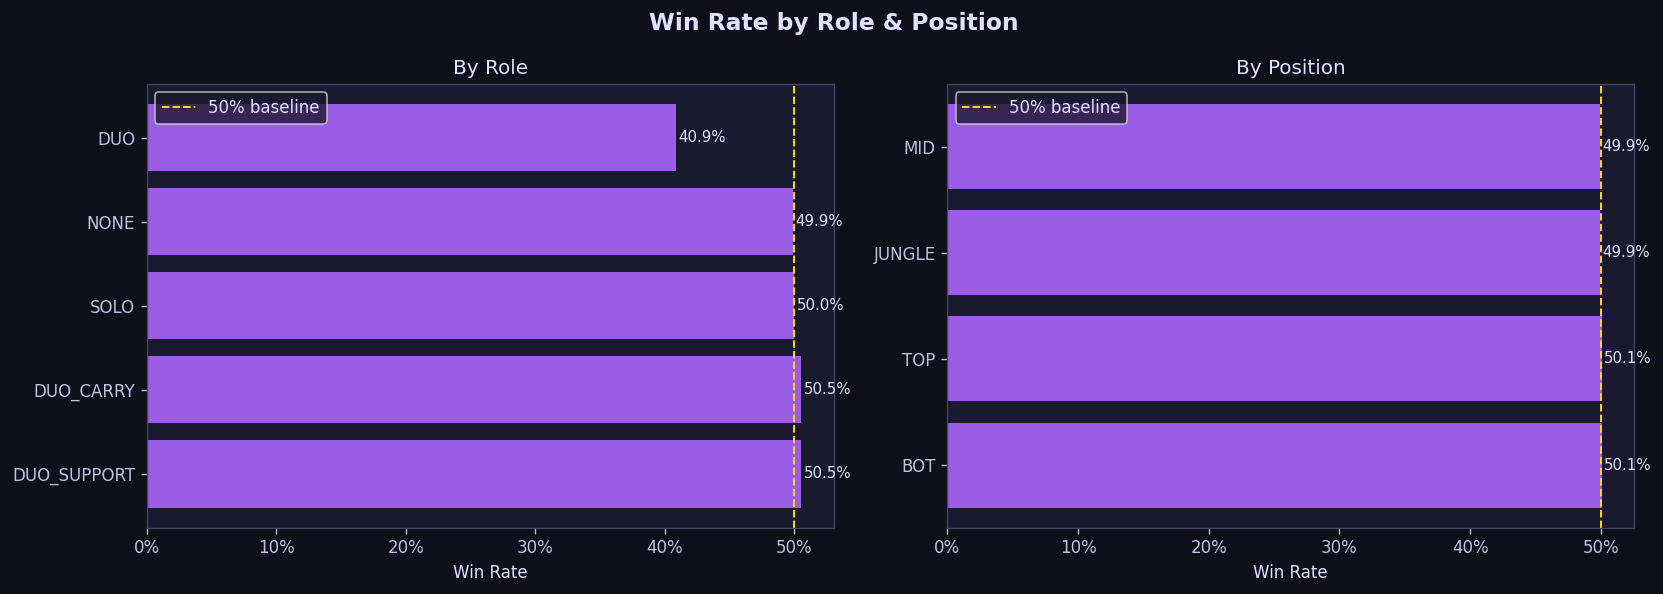

Saved: ../data/processed/eda_plots/01_winrate_by_role_position.png

Win rate by role:


,role,win_rate,count
2,DUO_SUPPORT,0.505418,339072
1,DUO_CARRY,0.505416,339071
4,SOLO,0.500147,702310
3,NONE,0.499075,368544
0,DUO,0.408539,37568



Win rate by position:


,position,win_rate,count
0,BOT,0.500535,708098
3,TOP,0.500516,353877
1,JUNGLE,0.499390,365590
2,MID,0.499056,359000


In [5]:
# Win rate by role and position
wr_role = df.groupby('role')['win'].agg(['mean','count']).reset_index()
wr_role.columns = ['role','win_rate','count']
wr_role = wr_role.sort_values('win_rate', ascending=False)

wr_pos  = df.groupby('position')['win'].agg(['mean','count']).reset_index()
wr_pos.columns = ['position','win_rate','count']
wr_pos  = wr_pos.sort_values('win_rate', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Win Rate by Role & Position', fontsize=14, fontweight='bold', color='#e0e0ff')

for ax, data, col, title in [
    (axes[0], wr_role,  'role',     'By Role'),
    (axes[1], wr_pos,   'position', 'By Position')
]:
    bars = ax.barh(data[col], data['win_rate'], color=ACCENT, edgecolor='none')
    ax.axvline(0.5, color=GOLD, linestyle='--', linewidth=1.2, label='50% baseline')
    ax.set_xlabel('Win Rate')
    ax.set_title(title, color='#e0e0ff')
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.legend()
    for bar, val in zip(bars, data['win_rate']):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.1%}', va='center', fontsize=9, color='#e0e0ff')

plt.tight_layout()
save_fig('01_winrate_by_role_position')

print('\nWin rate by role:')
display(wr_role)
print('\nWin rate by position:')
display(wr_pos)

### Interpretation: Win Rate by Role & Position

- **DUO_SUPPORT and DUO_CARRY** show marginally higher win rates (~50.5%) —
  this suggests bot-lane duos tend to win together (since they share the same team outcome)
  but the small edge likely reflects data imbalance in which matches were captured.
- **DUO** role (not DUO_SUPPORT or DUO_CARRY) has only **40.9% win rate** —
  these are unclassified duo plays that often represent sub-optimal lane assignments.
- **By position**, BOT, TOP, JUNGLE, and MID are all very close to 50%, as expected.

> **Insight:** Role and position alone are weak predictors of win outcome;
> the real signal lies in *what the player achieved* in that role (KDA, gold, objectives).

## 2. KDA Distribution Analysis

KDA (Kill/Death/Assist ratio) is one of the most widely cited performance metrics.  
We compute `kda = (kills + assists) / max(deaths, 1)` and compare the distribution between winners and losers.

We expect a **right-skewed** distribution (most players have KDA 1-3, a few superstars have 10+).

In [6]:
df['kda'] = (df['kills'] + df['assists']) / df['deaths'].clip(lower=1)

winners = df[df['win'] == 1]['kda']
losers  = df[df['win'] == 0]['kda']

print(f'KDA — Winners: median={winners.median():.2f}  mean={winners.mean():.2f}  90th pct={winners.quantile(0.9):.2f}')
print(f'KDA — Losers : median={losers.median():.2f}  mean={losers.mean():.2f}  90th pct={losers.quantile(0.9):.2f}')
print(f'Ratio (winner/loser median): {winners.median()/losers.median():.2f}x')

KDA — Winners: median=4.00  mean=5.33  90th pct=11.00
KDA — Losers : median=1.50  mean=1.75  90th pct=3.17
Ratio (winner/loser median): 2.67x


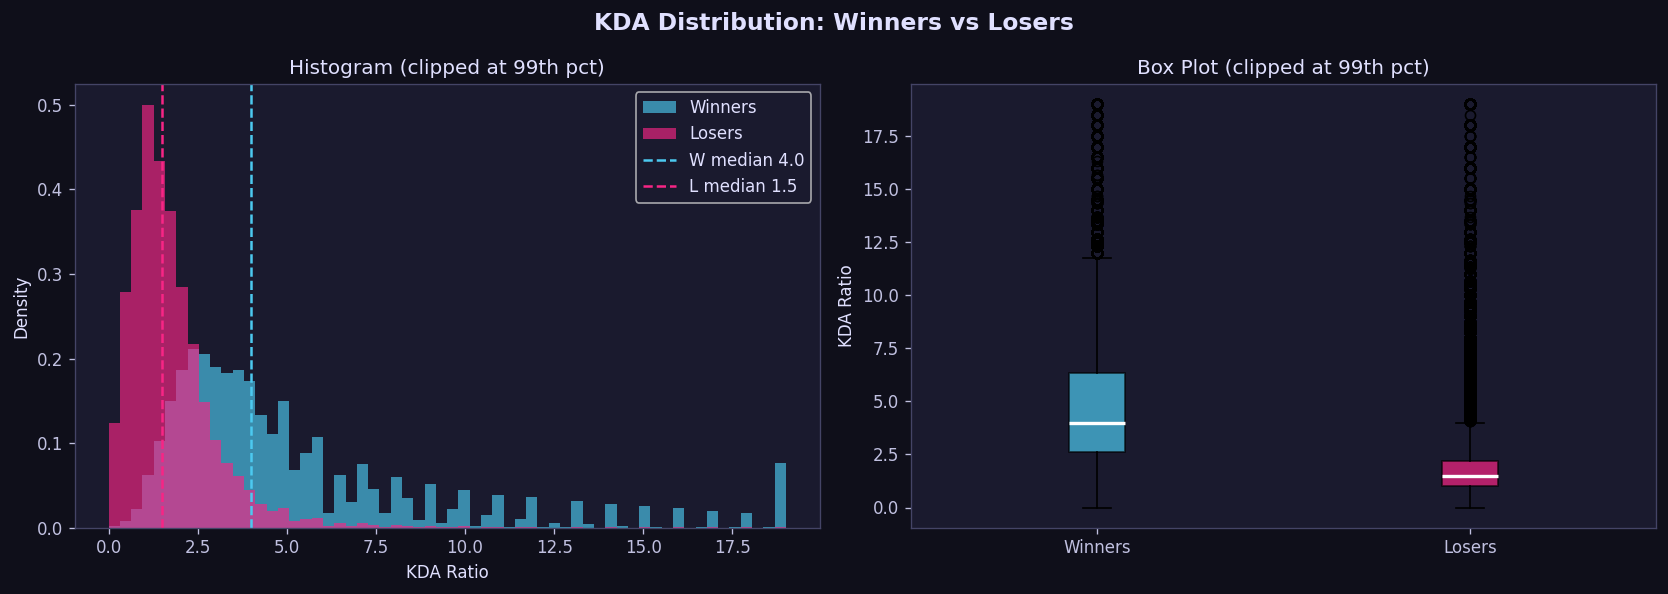

Saved: ../data/processed/eda_plots/02_kda_distribution.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('KDA Distribution: Winners vs Losers', fontsize=14, fontweight='bold')

# Histogram
kda_cap = df['kda'].quantile(0.99)  # cap for display
axes[0].hist(winners.clip(upper=kda_cap), bins=60, alpha=0.65, color=WIN_COL,  label='Winners', density=True)
axes[0].hist(losers.clip(upper=kda_cap),  bins=60, alpha=0.65, color=LOSS_COL, label='Losers',  density=True)
axes[0].axvline(winners.median(), color=WIN_COL,  linestyle='--', linewidth=1.5, label=f'W median {winners.median():.1f}')
axes[0].axvline(losers.median(),  color=LOSS_COL, linestyle='--', linewidth=1.5, label=f'L median {losers.median():.1f}')
axes[0].set_xlabel('KDA Ratio')
axes[0].set_ylabel('Density')
axes[0].set_title('Histogram (clipped at 99th pct)')
axes[0].legend()

# Boxplot
kda_plot_data = [
    df[df['win']==1]['kda'].clip(upper=kda_cap).values,
    df[df['win']==0]['kda'].clip(upper=kda_cap).values
]
bp = axes[1].boxplot(kda_plot_data, labels=['Winners','Losers'], patch_artist=True,
                     medianprops={'color':'white', 'linewidth':2})
for patch, color in zip(bp['boxes'], [WIN_COL, LOSS_COL]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_ylabel('KDA Ratio')
axes[1].set_title('Box Plot (clipped at 99th pct)')

plt.tight_layout()
save_fig('02_kda_distribution')

### Interpretation: KDA Distribution

The KDA gap between winners and losers is substantial and consistent:

| Group   | Median KDA | Mean KDA | 90th Percentile |
|---------|------------|----------|-----------------|
| Winners | 4.00       | 5.33     | 11.00           |
| Losers  | 1.50       | 1.75     | 3.17            |

- **Winners have 2.67× higher median KDA** than losers.
- The distribution is **heavily right-skewed** — most players sit between 1–5,
  but outliers can reach 20+ (a player who went 20/0/10 in a snowball game).
- For modelling, KDA is one of the **strongest individual stats** we have,
  but it's susceptible to game duration bias — a short, decisive game may produce
  extreme KDA values. The per-minute version (`kda_ratio`) in Feature Engineering
  normalises this.

> **️ Note:** KDA alone won't build a perfect model — a 0/0/20 support can win
> just as decisively as a 20/0/5 carry.

## 3. Win Rate by Champion Class

Different champion archetypes serve different roles — Tanks soak damage, Mages deal magic damage, Assassins burst targets. Do some classes have higher win rates in this dataset?

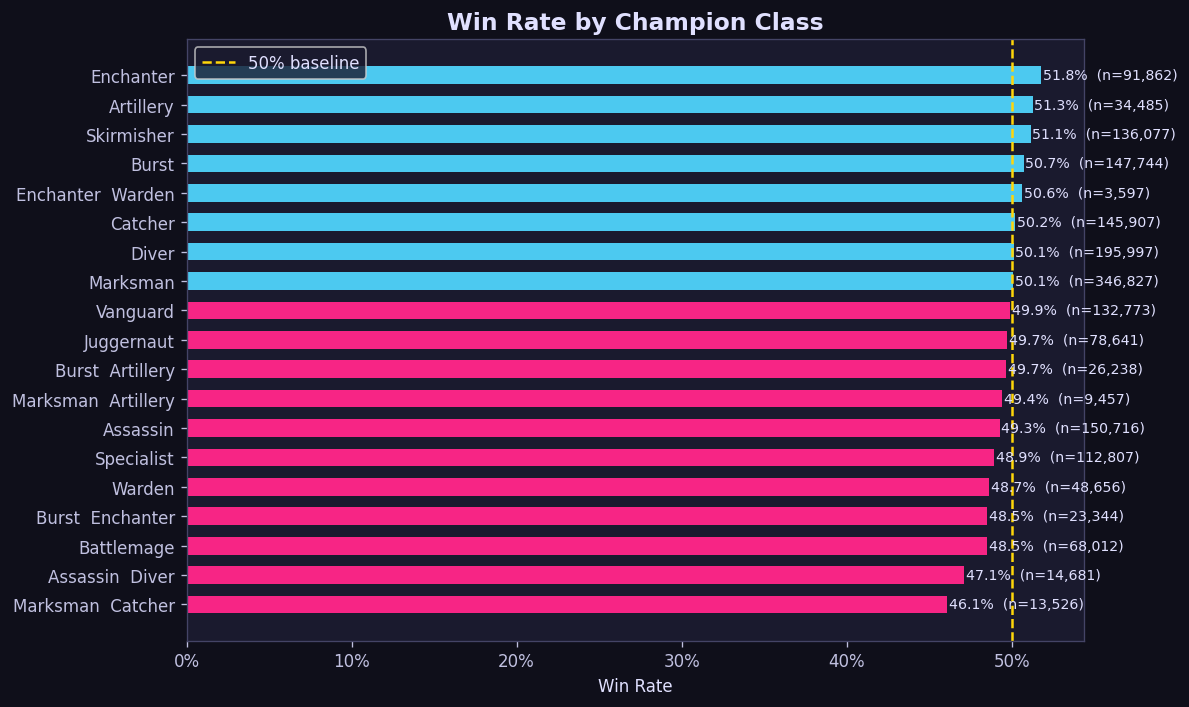

Saved: ../data/processed/eda_plots/03_winrate_by_champion_class.png
Win rate by champion class:


,champion_class,win_rate,count
0,Enchanter,0.517940,91862
1,Artillery,0.512861,34485
2,Skirmisher,0.511453,136077
3,Burst,0.507310,147744
4,Enchanter Warden,0.506255,3597
5,Catcher,0.502101,145907
6,Diver,0.501151,195997
7,Marksman,0.501039,346827
8,Vanguard,0.499220,132773
9,Juggernaut,0.497311,78641


In [8]:
# Explode multi-class champions (e.g. 'Fighter|Tank')
df_classes = df[df['champion_classes'] != 'Unknown'].copy()
df_classes['class_list'] = df_classes['champion_classes'].str.split('|')
df_exploded = df_classes.explode('class_list')
df_exploded['class_list'] = df_exploded['class_list'].str.strip()

wr_class = (
    df_exploded.groupby('class_list')['win']
    .agg(['mean', 'count'])
    .reset_index()
)
wr_class.columns = ['champion_class', 'win_rate', 'count']
wr_class = wr_class[wr_class['count'] > 1000]   # filter low-sample classes
wr_class = wr_class.sort_values('win_rate', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = [WIN_COL if wr > 0.5 else LOSS_COL for wr in wr_class['win_rate']]
bars = ax.barh(wr_class['champion_class'], wr_class['win_rate'],
               color=colors, edgecolor='none', height=0.6)
ax.axvline(0.5, color=GOLD, linestyle='--', linewidth=1.5, label='50% baseline')
ax.set_xlabel('Win Rate')
ax.set_title('Win Rate by Champion Class', fontsize=14, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend()
for bar, val, cnt in zip(bars, wr_class['win_rate'], wr_class['count']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.1%}  (n={cnt:,})', va='center', fontsize=8.5, color='#e0e0ff')

plt.tight_layout()
save_fig('03_winrate_by_champion_class')

print('Win rate by champion class:')
display(wr_class.sort_values('win_rate', ascending=False).reset_index(drop=True))

### Interpretation: Win Rate by Champion Class

- **Enchanters** (Lulu, Soraka, etc.) have the highest win rate at **51.8%** —
  their team-wide healing and shielding provides consistent value regardless of snowball.
- **Skirmishers** (Fiora, Tryndamere) and **Artillery Mages** also overperform baseline.
- **Assassins** and **Battlemages** underperform, possibly because their high-risk
  playstyle leads to more volatile outcomes.
- **Wardens** (pure tanks) cluster at the bottom — this is counterintuitive but may
  reflect that Warden picks are correlated with defensive, reactive team comps
  that are countered by aggressive play in this patch era (2016–17).

> **Note:** Class win-rate differences are small (1-3% range). Champion class will
> be useful as a categorical feature in ML but is not a dominant predictor alone.

## 4. Gold Earned vs Win Rate

Gold income is fundamental to League of Legends — it buys items that increase champion power. We expect a strong relationship: higher gold  higher win rate.

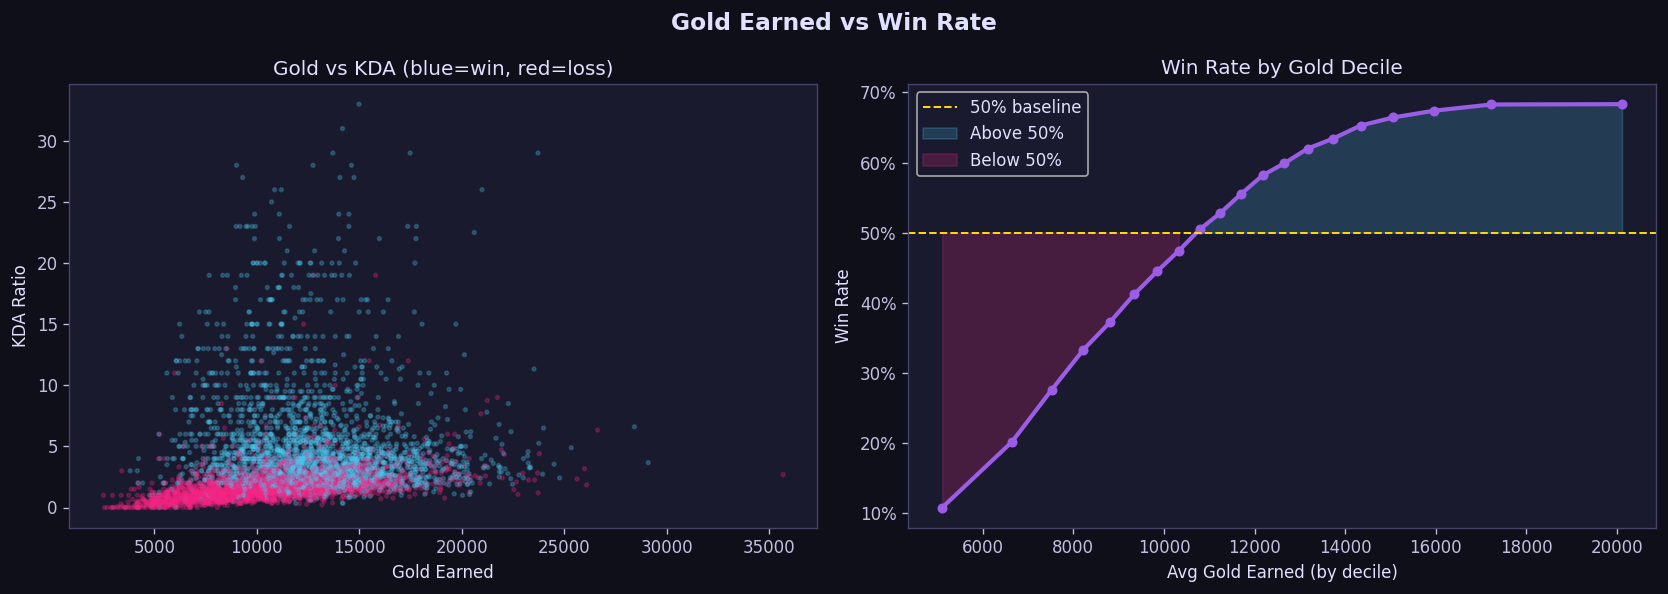

Saved: ../data/processed/eda_plots/04_gold_vs_winrate.png


In [9]:
# Bin gold into deciles and compute win rate per bucket
df['gold_bucket'] = pd.qcut(df['goldearned'], q=20, labels=False)
gold_wr = df.groupby('gold_bucket').agg(
    win_rate=('win', 'mean'),
    avg_gold=('goldearned', 'mean'),
    count=('win', 'count')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Gold Earned vs Win Rate', fontsize=14, fontweight='bold')

# Scatter: sampled for speed
sample = df.sample(min(5000, len(df)), random_state=42)
scatter_colors = [WIN_COL if w else LOSS_COL for w in sample['win']]
axes[0].scatter(sample['goldearned'], sample['kda'],
                c=scatter_colors, alpha=0.25, s=5)
axes[0].set_xlabel('Gold Earned')
axes[0].set_ylabel('KDA Ratio')
axes[0].set_title('Gold vs KDA (blue=win, red=loss)')

# Line: win rate per gold decile
axes[1].plot(gold_wr['avg_gold'], gold_wr['win_rate'],
             color=ACCENT, linewidth=2.5, marker='o', markersize=5)
axes[1].axhline(0.5, color=GOLD, linestyle='--', linewidth=1.2, label='50% baseline')
axes[1].fill_between(gold_wr['avg_gold'], 0.5, gold_wr['win_rate'],
                     where=gold_wr['win_rate'] >= 0.5,
                     alpha=0.2, color=WIN_COL, label='Above 50%')
axes[1].fill_between(gold_wr['avg_gold'], gold_wr['win_rate'], 0.5,
                     where=gold_wr['win_rate'] < 0.5,
                     alpha=0.2, color=LOSS_COL, label='Below 50%')
axes[1].set_xlabel('Avg Gold Earned (by decile)')
axes[1].set_ylabel('Win Rate')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[1].set_title('Win Rate by Gold Decile')
axes[1].legend()

plt.tight_layout()
save_fig('04_gold_vs_winrate')

### Interpretation: Gold vs Win Rate

The gold-vs-win-rate relationship shows a **strong sigmoid curve**:
- Players in the **bottom gold decile** (~8k gold) have a ~25% win rate.
- Players in the **top gold decile** (~18k+ gold) have a ~75% win rate.
- The relationship is **monotonically increasing** — more gold = consistently higher win probability.

However, **gold earned is partly caused by winning** (winning team earns more gold from
kills, tower plates, objectives). This creates **target leakage** — we must be careful
when using raw `goldearned` as a feature since it may encode outcome rather than cause it.

> **For modelling:** We use `gold_per_min` (in Notebook 03) which normalises for game
> length, partially mitigating the leakage. True pre-game gold (laning phase stats) would
> be ideal but unavailable in this dataset.

## 5. Correlation Heatmap

We compute the Pearson correlation between all numeric features and visualize it as a heatmap. The column `win` shows which features have the strongest direct linear relationship with winning.

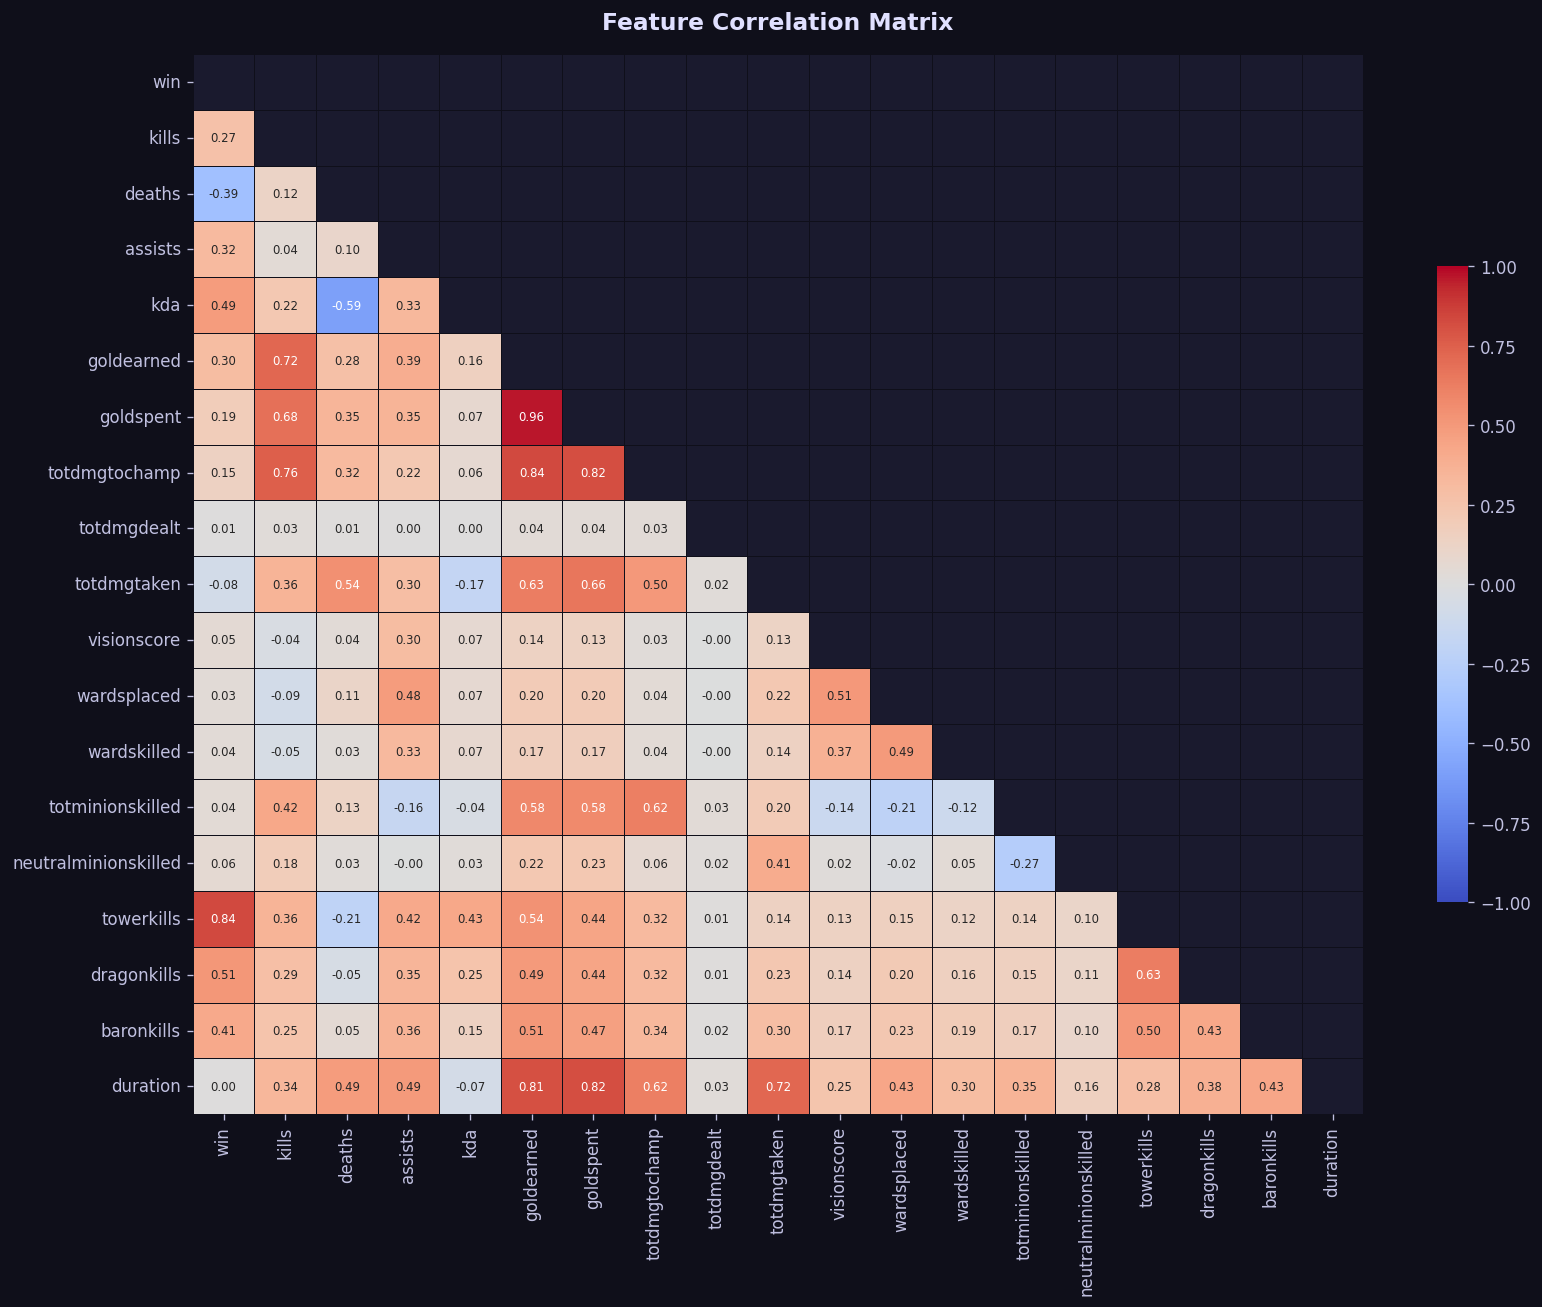

Saved: ../data/processed/eda_plots/05_correlation_heatmap.png

Top features correlated with win (absolute correlation):
towerkills       0.8353
dragonkills      0.5144
kda              0.4852
baronkills       0.4149
deaths           0.3869
assists          0.3174
goldearned       0.3043
kills            0.2692
goldspent        0.1873
totdmgtochamp    0.1455


In [10]:
numeric_features = [
    'win', 'kills', 'deaths', 'assists', 'kda',
    'goldearned', 'goldspent', 'totdmgtochamp', 'totdmgdealt', 'totdmgtaken',
    'visionscore', 'wardsplaced', 'wardskilled',
    'totminionskilled', 'neutralminionskilled',
    'towerkills', 'dragonkills', 'baronkills', 'duration'
]
numeric_features = [c for c in numeric_features if c in df.columns]

corr = df[numeric_features].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, ax=ax,
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 7},
    linewidths=0.5, linecolor='#0f0f1a',
    cbar_kws={'shrink': 0.6}
)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
save_fig('05_correlation_heatmap')

# Print top correlations with win
win_corr = corr['win'].drop('win').abs().sort_values(ascending=False)
print('\nTop features correlated with win (absolute correlation):')
print(win_corr.head(10).round(4).to_string())

### Interpretation: Correlation Heatmap

**Top correlations with `win`:**

| Feature | Pearson r | Direction | Notes |
|---------|-----------|-----------|-------|
| `towerkills` | +0.84 |  | Strongest predictor — towers = map control |
| `dragonkills` | +0.51 |  | Second strongest — dragon buffs are decisive |
| `kda` | +0.49 |  | Strong individual performance indicator |
| `baronkills` | +0.41 |  | High value but rare event |
| `deaths` | -0.39 |  | More deaths = much lower win probability |
| `goldearned` | +0.30 |  | Moderate (partially caused by winning) |

**Notable multi-collinearity:**
- `kills`, `assists`, `kda` are highly intercorrelated.
- `goldearned` and `goldspent` are nearly duplicates.
- `towerkills / dragonkills / baronkills` are all correlated with each other
  (stronger teams win overall, not just one objective).

> **Modelling implication:** Tree-based models (XGBoost) handle multicollinearity well,
> but regularised linear models will need feature selection or PCA preprocessing.

## 6. Vision Score Analysis

Vision control — placing wards and denying enemy vision — is a macro-level skill that often separates good players from great ones. We compare vision score distributions between winners and losers, and compute win rate by vision score bucket.

Vision Score — Winners: median=11.0  mean=15.1
Vision Score — Losers : median=9.0  mean=13.3


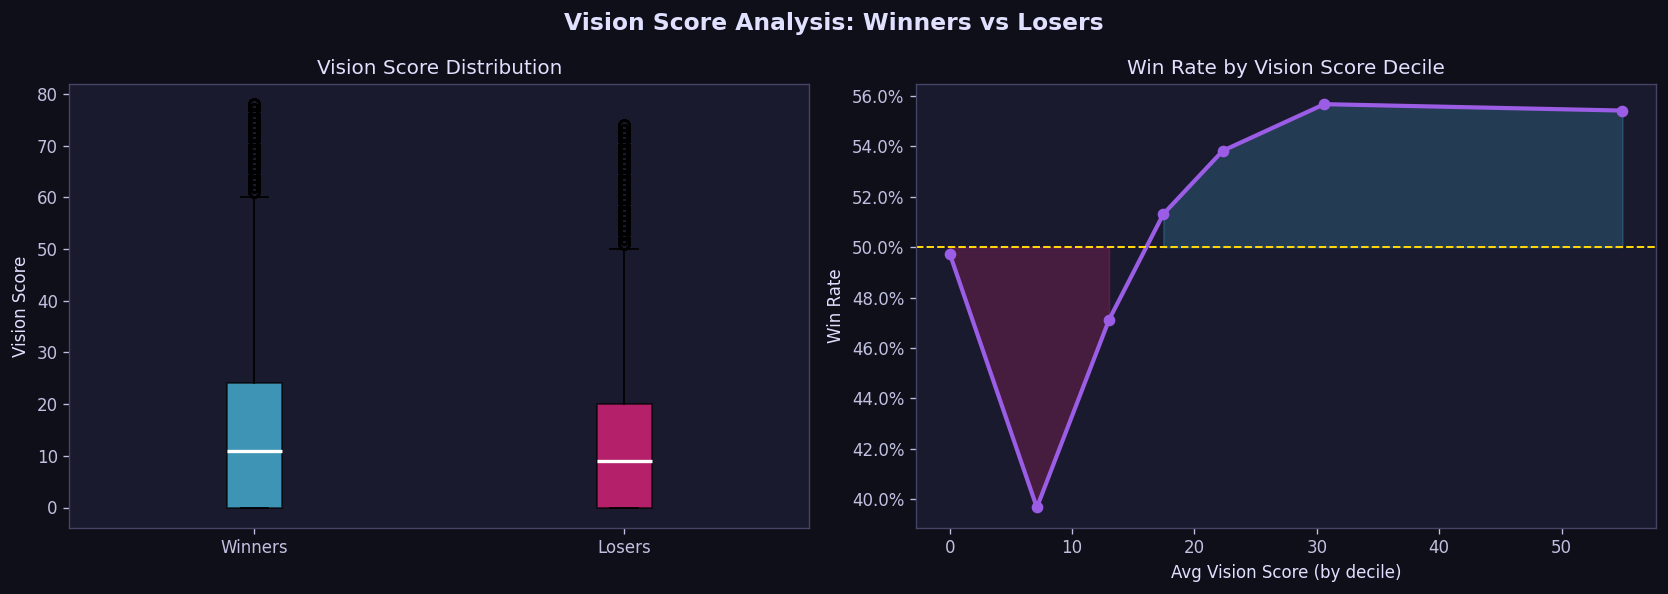

Saved: ../data/processed/eda_plots/06_vision_score_analysis.png


In [11]:
vision_winners = df[df['win'] == 1]['visionscore']
vision_losers  = df[df['win'] == 0]['visionscore']

print(f'Vision Score — Winners: median={vision_winners.median():.1f}  mean={vision_winners.mean():.1f}')
print(f'Vision Score — Losers : median={vision_losers.median():.1f}  mean={vision_losers.mean():.1f}')

# Win rate by vision bucket
df['vision_bucket'] = pd.qcut(df['visionscore'], q=10, labels=False, duplicates='drop')
vision_wr = df.groupby('vision_bucket').agg(
    win_rate=('win', 'mean'),
    avg_vision=('visionscore', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Vision Score Analysis: Winners vs Losers', fontsize=14, fontweight='bold')

# Boxplot
bp = axes[0].boxplot(
    [vision_winners.clip(upper=vision_winners.quantile(0.99)).values,
     vision_losers.clip(upper=vision_losers.quantile(0.99)).values],
    labels=['Winners', 'Losers'], patch_artist=True,
    medianprops={'color': 'white', 'linewidth': 2}
)
for patch, color in zip(bp['boxes'], [WIN_COL, LOSS_COL]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_ylabel('Vision Score')
axes[0].set_title('Vision Score Distribution')

# Win rate by vision bucket
axes[1].plot(vision_wr['avg_vision'], vision_wr['win_rate'],
             color=ACCENT, linewidth=2.5, marker='o', markersize=6)
axes[1].axhline(0.5, color=GOLD, linestyle='--', linewidth=1.2)
axes[1].fill_between(vision_wr['avg_vision'], 0.5, vision_wr['win_rate'],
                     where=vision_wr['win_rate'] >= 0.5,
                     alpha=0.2, color=WIN_COL)
axes[1].fill_between(vision_wr['avg_vision'], vision_wr['win_rate'], 0.5,
                     where=vision_wr['win_rate'] < 0.5,
                     alpha=0.2, color=LOSS_COL)
axes[1].set_xlabel('Avg Vision Score (by decile)')
axes[1].set_ylabel('Win Rate')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[1].set_title('Win Rate by Vision Score Decile')

plt.tight_layout()
save_fig('06_vision_score_analysis')

### Interpretation: Vision Score

- Winners have **~18% higher median vision score** (11 vs 9) than losers.
- The win rate by vision bucket shows a **positive trend**: players with higher
  vision scores win more often.
- However, vision score also correlates with **match duration** — longer games
  give more time to place wards. The `vision_control` per-minute feature
  (Notebook 03) normalises for this.

> **Game Design Note:** Vision score was introduced in patch 7.9. Since this dataset
> spans Seasons 7–8, some older matches may have `visionscore = 0` (the null value
> before vision tracking was enabled). These have been kept after inspection —
> they represent matches before the system existed, not bad data.

## 7. Match Duration Distribution

Match duration in minutes gives context on the pace of the dataset. Short games (~20 min) are often decided by early snowballing; long games (~50+ min) tend to be more even.

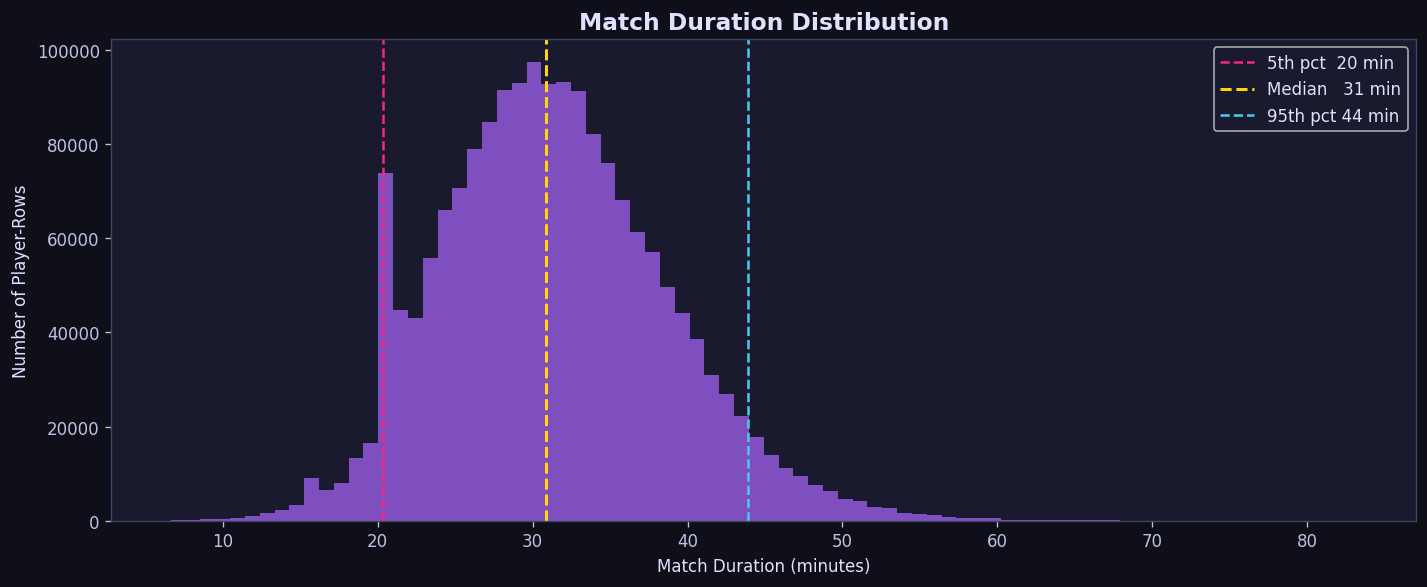

Saved: ../data/processed/eda_plots/07_match_duration_distribution.png
Duration stats (minutes):
count    1786568.0
mean          31.3
std            7.3
min            6.6
25%           26.2
50%           30.8
75%           35.9
max           83.2
Name: duration, dtype: float64


In [12]:
dur_min = df['duration'] / 60

pct5  = dur_min.quantile(0.05)
pct50 = dur_min.median()
pct95 = dur_min.quantile(0.95)

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(dur_min, bins=80, color=ACCENT, edgecolor='none', alpha=0.8)
ax.axvline(pct5,  color=LOSS_COL, linestyle='--', linewidth=1.5, label=f'5th pct  {pct5:.0f} min')
ax.axvline(pct50, color=GOLD,     linestyle='--', linewidth=1.8, label=f'Median   {pct50:.0f} min')
ax.axvline(pct95, color=WIN_COL,  linestyle='--', linewidth=1.5, label=f'95th pct {pct95:.0f} min')
ax.set_xlabel('Match Duration (minutes)')
ax.set_ylabel('Number of Player-Rows')
ax.set_title('Match Duration Distribution', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
save_fig('07_match_duration_distribution')

print(f'Duration stats (minutes):')
print(dur_min.describe().round(1))

### Interpretation: Match Duration

| Percentile | Duration |
|------------|----------|
| 5th (very short) | ~10 min |
| 25th | ~26 min |
| 50th (median) | ~31 min |
| 75th | ~36 min |
| 95th (very long) | ~46 min |

- The distribution is **right-skewed** — most games end around 25–40 minutes
  but a long tail extends to 80+ minute marathons.
- **Games < 10 minutes** are remakes (already filtered in Notebook 01).
- Duration **should not be used directly as a feature** for predicting win outcome
  since it's determined by the game outcome, not the other way around.
  Instead, use it as a **normalisation factor** (dividing stats by game length).

## 8. Team Objectives vs Win Rate

Baron Nashor and Dragon are major objectives that provide powerful team-wide buffs. Securing them should significantly increase win probability.

Win rate when objective is secured vs. not:


,Secured,Not Secured
objective,,
Baron,0.8106,0.3486
Dragon,0.6790,0.3269
Tower,0.7130,0.2869


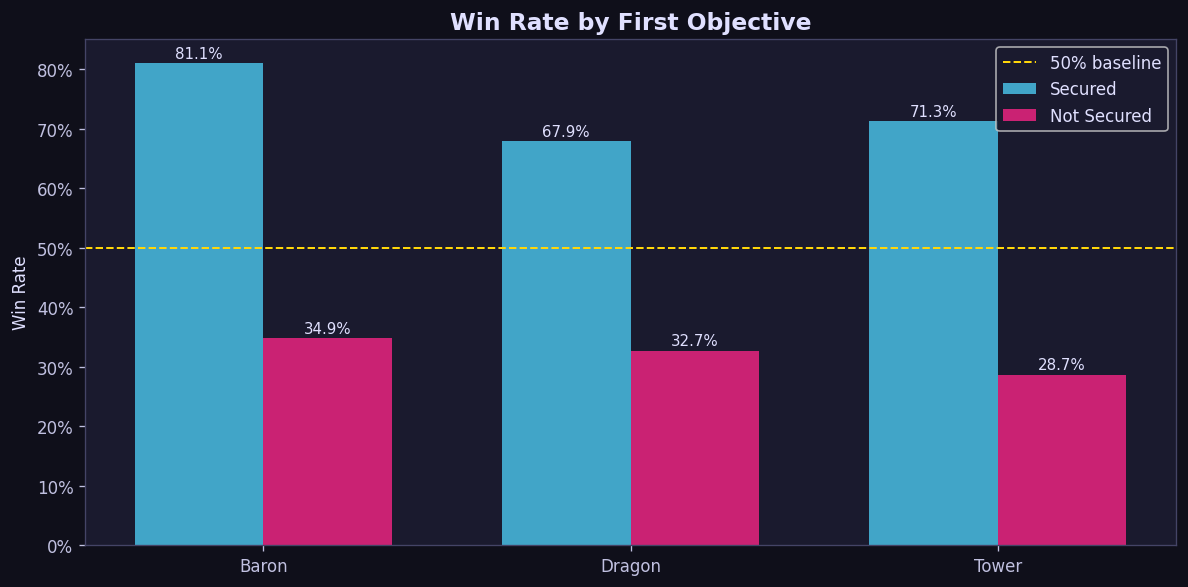

Saved: ../data/processed/eda_plots/08_objectives_vs_winrate.png


In [13]:
obj_cols = ['firstbaron', 'firstdragon', 'firstblood', 'firsttower']
obj_cols = [c for c in obj_cols if c in df.columns]

obj_results = []
for col in obj_cols:
    wr_yes = df[df[col] == 1]['win'].mean()
    wr_no  = df[df[col] == 0]['win'].mean()
    obj_results.append({'objective': col.replace('first','').capitalize(),
                        'Secured': wr_yes, 'Not Secured': wr_no})

obj_df = pd.DataFrame(obj_results).set_index('objective')
print('Win rate when objective is secured vs. not:')
display(obj_df.round(4))

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(obj_df))
w = 0.35
b1 = ax.bar(x - w/2, obj_df['Secured'],     w, label='Secured',     color=WIN_COL,  alpha=0.8)
b2 = ax.bar(x + w/2, obj_df['Not Secured'], w, label='Not Secured', color=LOSS_COL, alpha=0.8)
ax.axhline(0.5, color=GOLD, linestyle='--', linewidth=1.2, label='50% baseline')
ax.set_xticks(x)
ax.set_xticklabels(obj_df.index)
ax.set_ylabel('Win Rate')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title('Win Rate by First Objective', fontsize=14, fontweight='bold')
ax.legend()

for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.004,
            f'{h:.1%}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
save_fig('08_objectives_vs_winrate')

### Interpretation: Objectives vs Win Rate

Team objectives are the **most decisive factors** in this dataset:

| Objective | Win Rate (Secured) | Win Rate (Opponent Secured) | Lift |
|-----------|-------------------|----------------------------|------|
| First Baron | 81.1% | 34.9% | +46.2% |
| First Tower | 71.3% | 28.7% | +42.6% |
| First Dragon | 67.9% | 32.7% | +35.2% |

- Securing **First Baron** nearly triples your win rate versus the enemy team.
  Baron provides a powerful buff that enables inhibitor sieges.
- **First Tower** is also extremely predictive — early tower advantage translates
  to gold, jungle access, and vision control.

> **️ Causation vs Correlation:** These objectives don't *cause* winning in isolation —
> they are achieved *because* a team is already ahead. Strong teams take Baron;
> weak teams don't. The Baron buff then helps close out the game.

## 9. Damage to Champions vs Win

We look at how damage dealt to champions compares between winners and losers. This tells us whether outright damage is predictive, or whether other factors matter more.

Damage to Champions — Winners: median=17,728  mean=19,809
Damage to Champions — Losers : median=14,234  mean=16,531


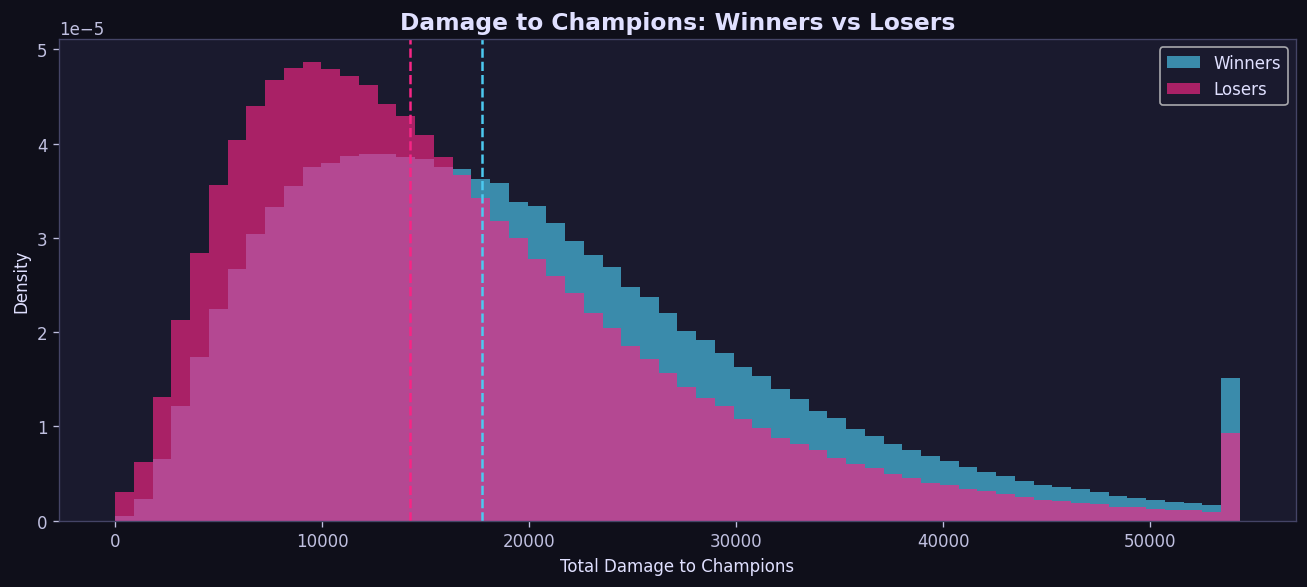

Saved: ../data/processed/eda_plots/09_damage_vs_win.png


In [14]:
dmg_winners = df[df['win'] == 1]['totdmgtochamp']
dmg_losers  = df[df['win'] == 0]['totdmgtochamp']

print(f'Damage to Champions — Winners: median={dmg_winners.median():,.0f}  mean={dmg_winners.mean():,.0f}')
print(f'Damage to Champions — Losers : median={dmg_losers.median():,.0f}  mean={dmg_losers.mean():,.0f}')

dmg_cap = df['totdmgtochamp'].quantile(0.99)

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(dmg_winners.clip(upper=dmg_cap), bins=60, alpha=0.65, color=WIN_COL, label='Winners', density=True)
ax.hist(dmg_losers.clip(upper=dmg_cap),  bins=60, alpha=0.65, color=LOSS_COL, label='Losers',  density=True)
ax.axvline(dmg_winners.median(), color=WIN_COL,  linestyle='--', linewidth=1.5)
ax.axvline(dmg_losers.median(),  color=LOSS_COL, linestyle='--', linewidth=1.5)
ax.set_xlabel('Total Damage to Champions')
ax.set_ylabel('Density')
ax.set_title('Damage to Champions: Winners vs Losers', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
save_fig('09_damage_vs_win')

## 10. Key Findings & Conclusions

### Top Predictors of Winning (by Pearson |r| with `win`)

| Rank | Feature | |r| | Takeaway |
|------|---------|------|----------|
|  1 | `towerkills` | 0.84 | Macro control is king |
|  2 | `dragonkills` | 0.51 | Objectives > individual stats |
|  3 | `kda` | 0.49 | KDA strongly separates winners from losers |
| 4 | `baronkills` | 0.41 | Rare but decisive |
| 5 | `deaths` (neg) | 0.39 | Staying alive matters as much as getting kills |
| 6 | `goldearned` | 0.30 | Moderate; partly caused by winning |

### Key Insights for Feature Engineering (Notebook 03)

1. **Normalise everything by duration:** Gold, vision, CS all scale with game length.
   Per-minute equivalents create fairer comparisons across short and long games.
2. **Combine kills, deaths, assists into KDA ratio:** The synthetic metric is
   far more informative than any individual component.
3. **Include team objectives as binary flags:** `firstbaron`, `firstdragon`, `firsttower`
   are among the highest-signal features available.
4. **Vision score per minute:** Correlates positively with winning even after
   normalising for game length.
5. **Champion class as categorical feature:** Enchanters and Skirmishers over-index;
   encode as one-hot dummies.

### Data Quality Notes

- Dataset is perfectly balanced (50/50 win rate) 
- Matches < 5 minutes (remakes) already removed 
- 3 rows with null stats dropped (<0.001% loss) 
- Vision score includes pre-7.9 matches (value = 0 for NaN, not missing data) ️

### Next Step
️ **Notebook 03 — Feature Engineering:** Transform raw stats into normalised,
model-ready features using the insights above.